# Fast Base Long Filter Strategy 2026

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import talib as ta


c:\Users\romeo\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
# Get Dataframe from Yahoo Finance
df = yf.download('BTC-USD', start='2018-01-01', end='2025-01-01')
df["Close"]
df["High"]
df["Low"]
df["Open"]
df["Volume"]
days = np.arange(len(df))
df["Days"] = days+1
#rearrange columns
df = df[["Days", "Open", "High", "Low", "Close", "Volume"]]
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Days,Open,High,Low,Close,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,
2018-01-01,1,14112.200195,14112.200195,13154.700195,13657.200195,10291200000
2018-01-02,2,13625.000000,15444.599609,13163.599609,14982.099609,16846600192
2018-01-03,3,14978.200195,15572.799805,14844.500000,15201.000000,16871900160
2018-01-04,4,15270.700195,15739.700195,14522.200195,15599.200195,21783199744
2018-01-05,5,15477.200195,17705.199219,15202.799805,17429.500000,23840899072


In [38]:
#-------------------/ Pretty Good Oscillator /-------------------#
PGO_length  = int(input("Enter the length for PGO: "))
upper_level = float(input("Enter the upper level for PGO: "))
lower_level = float(input("Enter the lower level for PGO: "))

def pgo(df, length=34):
    close = df['Close'].squeeze().values
    high  = df['High'].squeeze().values
    low   = df['Low'].squeeze().values

    sma = ta.SMA(close, timeperiod=length)
    atr = ta.ATR(high, low, close, timeperiod=length)
    return (close - sma) / atr

df['PGO'] = pgo(df, length=PGO_length)

df['Long PGO'] = np.where(df['PGO'] >= upper_level, True, False)
df['Short PGO'] = np.where(df['PGO'] <= lower_level, True, False)
df['color_PGO'] = np.where(df['Long PGO'], 'green', np.where(df['Short PGO'], 'red', 'gray'))


df.head()





Price,Days,Open,High,Low,Close,Volume,PGO,Long PGO,Short PGO,color_PGO,...,Long Gann,Short Gann,gann_color,Long Condition,Short Condition,Signal,entry,Returns,Strategy Returns,BH Returns
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,1,14112.200195,14112.200195,13154.700195,13657.200195,10291200000,NaN,False,False,gray,...,False,False,purple,False,False,0,NaN,NaN,NaN,NaN
2018-01-02,2,13625.000000,15444.599609,13163.599609,14982.099609,16846600192,NaN,False,False,gray,...,False,False,purple,False,False,0,0.0,1324.899414,0.0,109.701106
2018-01-03,3,14978.200195,15572.799805,14844.500000,15201.000000,16871900160,NaN,False,False,gray,...,False,False,purple,False,False,0,0.0,218.900391,0.0,111.303926
2018-01-04,4,15270.700195,15739.700195,14522.200195,15599.200195,21783199744,NaN,False,False,gray,...,False,False,purple,False,False,0,0.0,398.200195,0.0,114.219606
2018-01-05,5,15477.200195,17705.199219,15202.799805,17429.500000,23840899072,NaN,False,False,gray,...,False,False,purple,False,False,0,0.0,1830.299805,0.0,127.621326


In [5]:
# =================/ Linear Regression and Volatility /=================

lin_length = int(input("Enter Linear Regression length: "))
offset_length = int(input("Enter Linear Regression offset length: "))

close = df['Close'].squeeze().values #SQUEEZE TO 1D ARRAY
high  = df['High'].squeeze().values
low   = df['Low'].squeeze().values

lin_reg = ta.LINEARREG(close, timeperiod=lin_length)

# Apply offset t
lin_reg_offset = pd.Series(lin_reg).shift(offset_length).values


df["Linear Regression"] = lin_reg_offset
df["Long Linereg"] = np.where(close > df["Linear Regression"].values, True, False)
df["Short Linereg"] = np.where(close < df["Linear Regression"].values, True, False)

color_linereg = np.where(df["Long Linereg"], 'green', np.where(df["Short Linereg"], 'red', 'gray'))



In [48]:
#//========= / Standard Deviation EMA / =============//

ema_length = int(input("Enter EMA length for Standard Deviation: "))
std_multiplier = float(input("Enter Standard Deviation Multiplier: "))
close = df['Close'].squeeze().values

ema = ta.EMA(close, timeperiod=ema_length)
std = ta.STDDEV(close, timeperiod=ema_length) * std_multiplier

df["EMA"] = ema
df["EMA Upperband"] = df["EMA"] + std
df["EMA Lowerband"] = df["EMA"] - std

close_s = df["Close"]
upper_s = df["EMA Upperband"]
lower_s = df["EMA Lowerband"]

ema_trend = np.zeros(len(df), dtype=bool)

ema = ta.EMA(close, timeperiod=ema_length)
std = ta.STDDEV(close, timeperiod=ema_length) * std_multiplier

upperband = ema + std
lowerband = ema - std

df["EMA"] = ema
df['EMA Upperband'] = upperband
df['EMA Lowerband'] = lowerband
longema = np.where(close > df['EMA Upperband'].values, True, False)
shortema = np.where(close < df['EMA Lowerband'].values, True, False)

state = np.zeros(len(df), dtype=bool)

for i in range(len(df)):
    if longema[i]:
        state[i] = True
    elif shortema[i]:
        state[i] = False
    else:
        state[i] = state[i - 1] if i > 0 else False

df["EMA State"] = state

df["Long EMA"] = df["EMA State"]
df["Short EMA"] = ~df["EMA State"]

df["color_ema"] = np.where(df["Long EMA"], "green", "red")

df.head(300)

Price,Days,Open,High,Low,Close,Volume,PGO,Long PGO,Short PGO,color_PGO,...,Short Condition,Signal,entry,Returns,Strategy Returns,BH Returns,State,Long,Short,EMA State
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,1,14112.200195,14112.200195,13154.700195,13657.200195,10291200000,NaN,False,False,gray,...,False,0,NaN,NaN,NaN,NaN,False,False,True,False
2018-01-02,2,13625.000000,15444.599609,13163.599609,14982.099609,16846600192,NaN,False,False,gray,...,False,0,0.0,1324.899414,0.000000,109.701106,False,False,True,False
2018-01-03,3,14978.200195,15572.799805,14844.500000,15201.000000,16871900160,NaN,False,False,gray,...,False,0,0.0,218.900391,0.000000,111.303926,False,False,True,False
2018-01-04,4,15270.700195,15739.700195,14522.200195,15599.200195,21783199744,NaN,False,False,gray,...,False,0,0.0,398.200195,0.000000,114.219606,False,False,True,False
2018-01-05,5,15477.200195,17705.199219,15202.799805,17429.500000,23840899072,NaN,False,False,gray,...,False,0,0.0,1830.299805,0.000000,127.621326,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-10-23,296,6472.359863,6506.009766,6451.270020,6475.740234,3716150000,-0.385338,False,True,red,...,True,-1,0.0,-11.419922,11.419922,47.416309,False,False,True,False
2018-10-24,297,6478.890137,6521.990234,6468.859863,6495.839844,3424670000,-0.269013,False,True,red,...,True,-1,0.0,20.099609,-20.099609,47.563481,False,False,True,False


In [7]:
#//========= / Gann Theory For Loop / =============//
from typing_extensions import final


start = int(input("Enter start for Gann Theory: "))
end = int(input("Enter end for Gann Theory: "))
up_threshold = float(input("Enter Upper threshold for Gann Theory: "))
down_threshold = float(input("Enter Lower threshold for Gann Theory: "))
gann_threshold = -15 # This is a default value, you can adjust it based on your needs

def system_forloop(df, src_col, start, end):
    src = df[src_col].to_numpy()
    close = df["Close"].to_numpy()
    out = np.full(len(df), np.nan, dtype=float)

    for row in range(len(df)):
        if row < end:
            continue

        count = 0.0
        for i in range(start, end + 1):
            count += -1 if src[row - i] > close[row] else 1

        out[row] = count

    return out



    #for row in range(len(src)):
     #   count = 0.0
      #  for i in range(start, end + 1):
       #     lookback_idx = row - i          # "i bars ago" from current row
        #    if lookback_idx < 0:
        #        continue                    # not enough history yet, skip
        #    past_close = src[lookback_idx]
        #    count += -1 if past_close > src[row] else 1
        #result[row] = count



gann_theory_close = system_forloop(df, "Close", start, end)
gann_theory_high  = system_forloop(df, "High", start, end)
gann_theory_low   = system_forloop(df, "Low", start, end)

final_gann_theory = np.where(
    gann_theory_close > gann_threshold,
    gann_theory_high,
    gann_theory_low
)
df["Gann Theory For Loop"] = final_gann_theory

long_gann = (final_gann_theory[:-1] <= up_threshold) & (final_gann_theory[1:] > up_threshold)
short_gann = (final_gann_theory[:-1] >= down_threshold) & (final_gann_theory[1:] < down_threshold)

long_gann = np.insert(long_gann, 0, False)
short_gann = np.insert(short_gann, 0, False)


gann_sig = np.zeros(len(final_gann_theory))

for i in range(1, len(final_gann_theory)):
    if long_gann[i] and not short_gann[i]:
        gann_sig[i] = 1
    elif short_gann[i]:
        gann_sig[i] = -1
    else:
        gann_sig[i] = gann_sig[i-1]

df["Long Gann"] = np.where(gann_sig == 1, True, False)
df["Short Gann"] = np.where(gann_sig == -1, True, False)
df["gann_color"] = np.where(df["Long Gann"].values == 1, 'teal', np.where(df["Short Gann"].values == -1, 'purple', 'purple'))


In [56]:
## ====== / Strategy Conditioning / ====== ##
# Only Go Long When Both Base and Filter Conditions are Met
df["Long Condition"] = (
    (df["Long PGO"] == True) | (df["Long Linereg"] == True)) & ((df["Long Gann"] == True)) #| (df["Long EMA"] == True)

df["Short Condition"] = (
    (df["Short PGO"] == True) | (df["Short Linereg"] == True)) & (df["Short Gann"] == True)

df["Signal"] = np.where(df["Long Condition"] & df["Long Condition"].shift(1),1,0)
df["Signal"] = np.where(df["Short Condition"] & df["Short Condition"].shift(1),-1,df["Signal"])

df['entry'] = df['Signal'].diff()

df.head(350)

Price,Days,Open,High,Low,Close,Volume,PGO,Long PGO,Short PGO,color_PGO,...,Short Condition,Signal,entry,Returns,Strategy Returns,BH Returns,State,Long,Short,EMA State
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,1,14112.200195,14112.200195,13154.700195,13657.200195,10291200000,NaN,False,False,gray,...,False,0,NaN,NaN,NaN,NaN,False,False,True,False
2018-01-02,2,13625.000000,15444.599609,13163.599609,14982.099609,16846600192,NaN,False,False,gray,...,False,0,0.0,1324.899414,0.000000,109.701106,False,False,True,False
2018-01-03,3,14978.200195,15572.799805,14844.500000,15201.000000,16871900160,NaN,False,False,gray,...,False,0,0.0,218.900391,0.000000,111.303926,False,False,True,False
2018-01-04,4,15270.700195,15739.700195,14522.200195,15599.200195,21783199744,NaN,False,False,gray,...,False,0,0.0,398.200195,0.000000,114.219606,False,False,True,False
2018-01-05,5,15477.200195,17705.199219,15202.799805,17429.500000,23840899072,NaN,False,False,gray,...,False,0,0.0,1830.299805,0.000000,127.621326,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-12,346,3421.458252,3534.228516,3413.481445,3486.950195,4139364829,-4.647786,False,True,red,...,True,-1,0.0,62.362061,-62.362061,25.531955,False,False,True,False
2018-12-13,347,3487.879395,3489.739502,3298.132080,3313.677246,4343372456,-5.031315,False,True,red,...,True,-1,0.0,-173.272949,173.272949,24.263225,False,False,True,False


In [1]:
# returns
starting_equity = float(input("Enter the starting equity: "))
bh_equity = starting_equity
strategy_equity = starting_equity




df['Returns'] = (df["Close"]).diff() #plot buy and hold returns
df['Strategy Returns'] = df['Signal'] * df['Returns'] #plot strategy returns

# Buy and Hold Returns
df["BH Returns"] = bh_equity * (df["Close"] / df["Close"].shift(1)).cumprod()
df.head()

#Strategy Returns
close = df["Close"].values






NameError: name 'df' is not defined

Text(0, 0.5, 'Value')

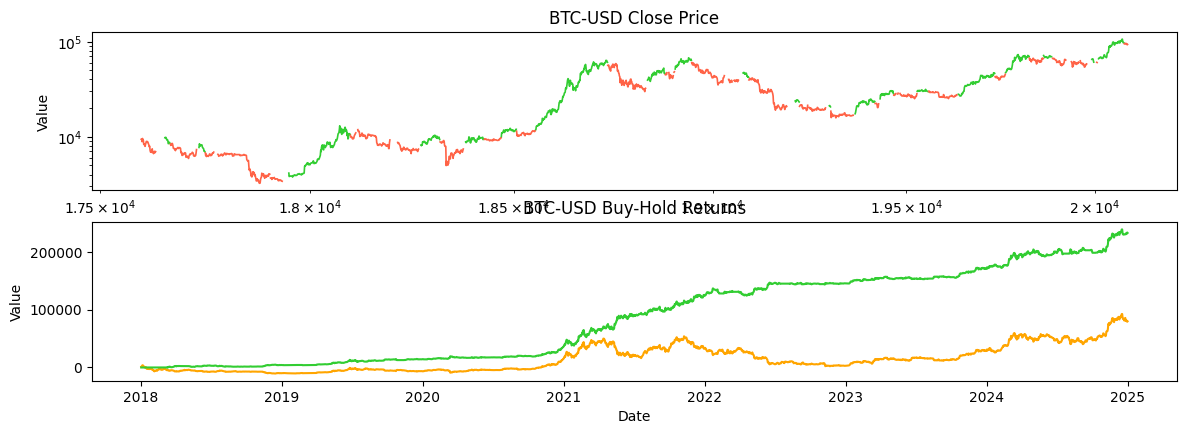

In [58]:
# Plottinfg
plt.figure(figsize=(14, 7))
close = df["Close"]
plt.subplot(3, 1, 1)
plt.loglog(df.index, close.where(df["Long Condition"] == True), color="limegreen", linewidth=1.2)
plt.loglog(df.index, close.where(df["Short Condition"] == True), color="tomato", linewidth=1.2)
plt.loglog(df.index, close.where(df['entry'] == 2), color="blue", linewidth=1.2)
plt.loglog(df.index, close.where(df['entry'] == -2), color="purple", linewidth=1.2)
plt.title("BTC-USD Close Price")
plt.xlabel("Date")
plt.ylabel("Value")

plt.subplot(3, 1, 2)
plt.plot(df['Returns'].cumsum(), label="Buy-Hold Returns", color="orange")
plt.plot(df["Strategy Returns"].cumsum(), label="Strategy Returns", color="limegreen")
plt.title("BTC-USD Buy-Hold Returns")
plt.xlabel("Date")
plt.ylabel("Value")



In [59]:
## ================/ Backtesting /================

print("Backtesting Results:")
total_trades = df['entry'].abs().sum()
net_profit = (df['Strategy Returns'].sum())
print("Backtesting Results:")                       
print(f"Net Profit: {net_profit}")


Backtesting Results:
Backtesting Results:
Net Profit: 232504.81787109375


C:\Users\romeo\AppData\Local\Temp\ipykernel_14300\2501909295.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\romeo\AppData\Local\Temp\ipykernel_14300\2501909295.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


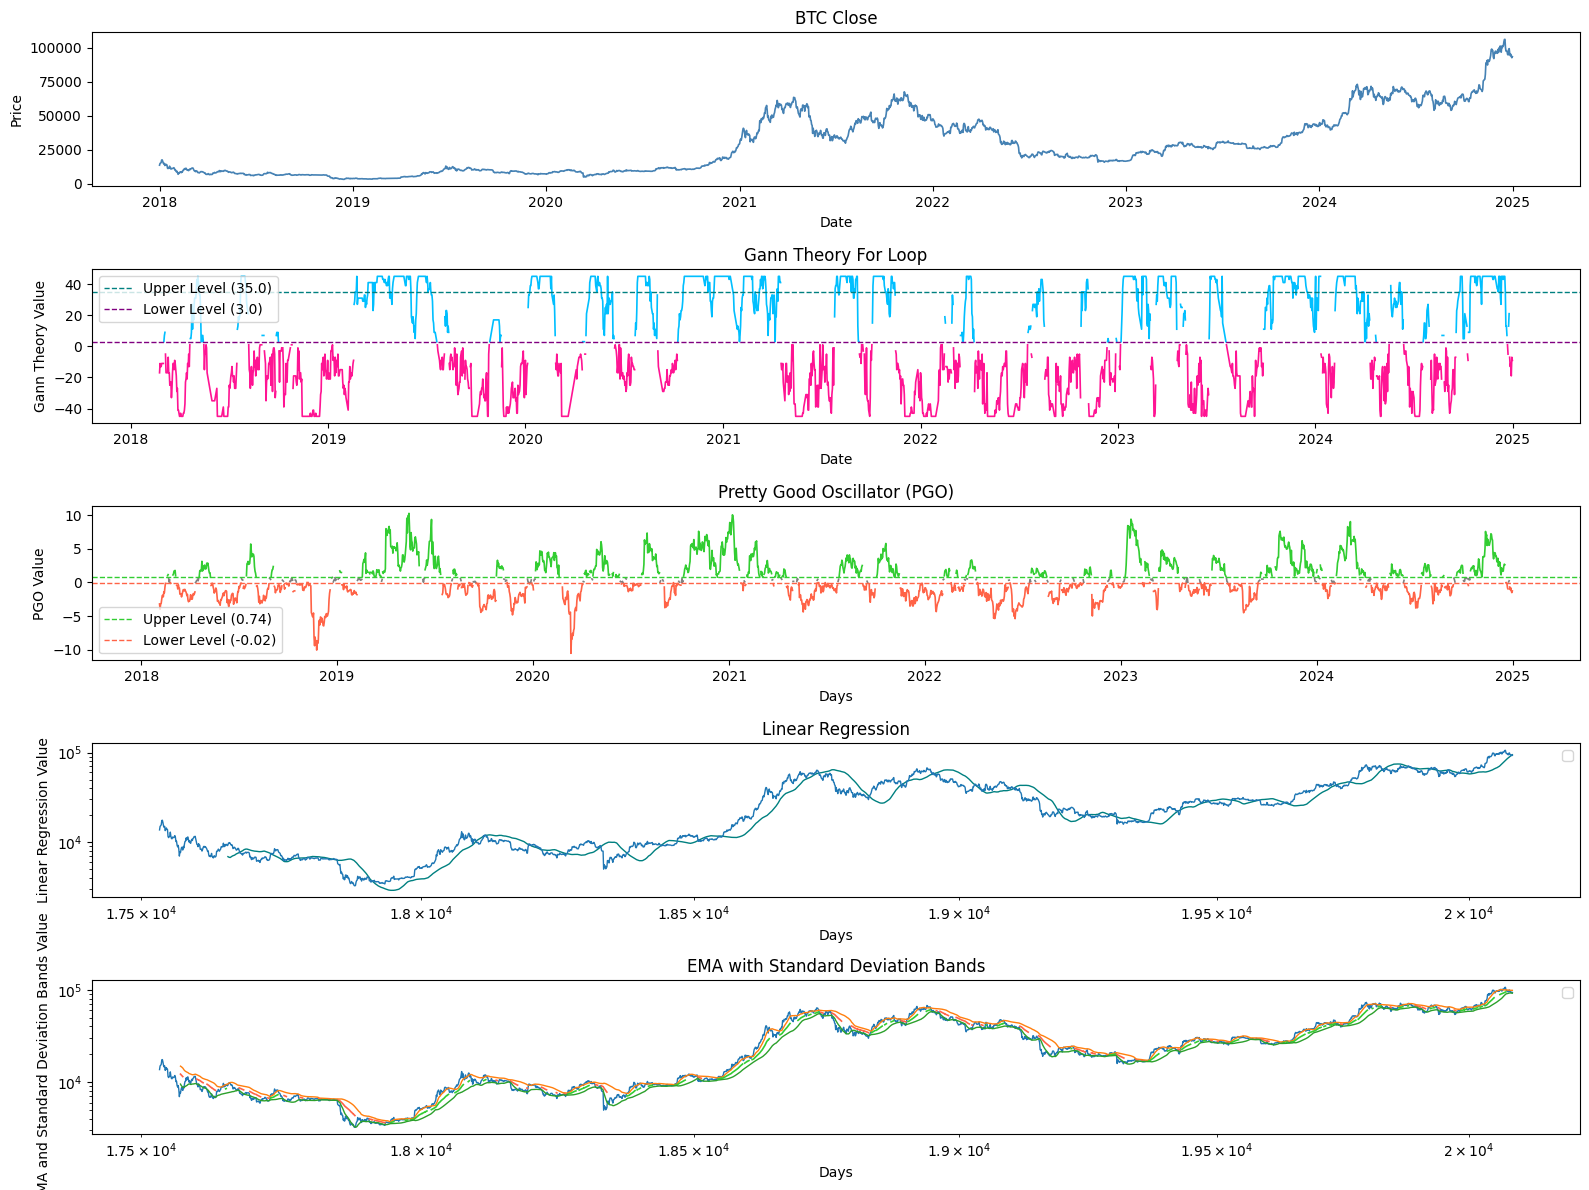

In [49]:
# Subplot for Oscillators
plt.figure(figsize=(16, 12))

plt.subplot(5, 1, 1)
plt.plot(df.index, df["Close"], linewidth=1.2, color="steelblue")
plt.title("BTC Close")
plt.xlabel("Date")
plt.ylabel("Price")

 
plt.subplot(5, 1, 2)
gann = df["Gann Theory For Loop"]
plt.plot(df.index, gann.where(gann >= down_threshold), color="deepskyblue", linewidth=1.2)
plt.plot(df.index, gann.where(gann < down_threshold), color="deeppink", linewidth=1.2)
plt.axhline(y=up_threshold, color='teal', linestyle='--', linewidth=1, label=f'Upper Level ({up_threshold})')
plt.axhline(y=down_threshold, color='purple', linestyle='--', linewidth=1, label=f'Lower Level ({down_threshold})')
plt.title("Gann Theory For Loop")
plt.xlabel("Date")
plt.ylabel("Gann Theory Value")
plt.legend()


plt.subplot(5, 1, 3)
pgo = df["PGO"]  
plt.plot(df.index, pgo.where(pgo >= upper_level), color="limegreen", linewidth=1.2)
plt.plot(df.index, pgo.where(pgo < lower_level), color="tomato", linewidth=1.2)
plt.plot(df.index, pgo.where((pgo >= lower_level) & (pgo < upper_level)), color="gray", linewidth=1.2)
plt.axhline(y=upper_level, color='limegreen', linestyle='--', linewidth=1, label=f'Upper Level ({upper_level})')
plt.axhline(y=lower_level, color='tomato', linestyle='--', linewidth=1, label=f'Lower Level ({lower_level})')
plt.title("Pretty Good Oscillator (PGO)")
plt.xlabel("Days")
plt.ylabel("PGO Value")
plt.legend()

plt.subplot(5, 1, 4)
plt.loglog(df["Linear Regression"], color="teal", linewidth=1)
plt.loglog(df["Close"], linewidth=1)
plt.title("Linear Regression")
plt.xlabel("Days")
plt.ylabel("Linear Regression Value")
plt.legend()


plt.subplot(5, 1, 5)
ema = df["EMA"]
plt.loglog(df["Close"], linewidth=1)
plt.loglog(df["EMA Upperband"],linewidth=1)
plt.loglog(df.index, ema.where(longema), color="limegreen", linewidth=1.2)
plt.loglog(df.index, ema.where(shortema), color="tomato", linewidth=1.2)
plt.loglog(df["EMA Lowerband"], linewidth=1)
plt.title("EMA with Standard Deviation Bands")
plt.xlabel("Days")
plt.ylabel("EMA and Standard Deviation Bands Value")
plt.legend()

plt.tight_layout()
plt.show()

